In [9]:
# Cell 1: Imports and load
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

raw_path = "../data/raw/credit_default.xls"
df = pd.read_excel(raw_path, header=1)
df.head()

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default payment next month
0,1,20000,2,2,1,24,2,2,-1,-1,...,0,0,0,0,689,0,0,0,0,1
1,2,120000,2,2,2,26,-1,2,0,0,...,3272,3455,3261,0,1000,1000,1000,0,2000,1
2,3,90000,2,2,2,34,0,0,0,0,...,14331,14948,15549,1518,1500,1000,1000,1000,5000,0
3,4,50000,2,2,1,37,0,0,0,0,...,28314,28959,29547,2000,2019,1200,1100,1069,1000,0
4,5,50000,1,2,1,57,-1,0,-1,0,...,20940,19146,19131,2000,36681,10000,9000,689,679,0


In [10]:
# Cell 2: Shape and columns
print(f"Shape: {df.shape}")
print("Columns:", df.columns.tolist())

Shape: (30000, 25)
Columns: ['ID', 'LIMIT_BAL', 'SEX', 'EDUCATION', 'MARRIAGE', 'AGE', 'PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6', 'BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6', 'default payment next month']


In [11]:
# Cell 3: Data types and missing values
print(df.dtypes)
print("\nMissing values per column:")
print(df.isnull().sum())

ID                            int64
LIMIT_BAL                     int64
SEX                           int64
EDUCATION                     int64
MARRIAGE                      int64
AGE                           int64
PAY_0                         int64
PAY_2                         int64
PAY_3                         int64
PAY_4                         int64
PAY_5                         int64
PAY_6                         int64
BILL_AMT1                     int64
BILL_AMT2                     int64
BILL_AMT3                     int64
BILL_AMT4                     int64
BILL_AMT5                     int64
BILL_AMT6                     int64
PAY_AMT1                      int64
PAY_AMT2                      int64
PAY_AMT3                      int64
PAY_AMT4                      int64
PAY_AMT5                      int64
PAY_AMT6                      int64
default payment next month    int64
dtype: object

Missing values per column:
ID                            0
LIMIT_BAL                 

In [12]:
# Cell 4: Rename columns (optional)
col_names = {
    'ID': 'id',
    'LIMIT_BAL': 'credit_limit',
    'SEX': 'sex',
    'EDUCATION': 'education',
    'MARRIAGE': 'marital_status',
    'AGE': 'age',
    'PAY_0': 'pay_status_sept',
    'PAY_2': 'pay_status_aug',
    'PAY_3': 'pay_status_jul',
    'PAY_4': 'pay_status_jun',
    'PAY_5': 'pay_status_may',
    'PAY_6': 'pay_status_apr',
    'BILL_AMT1': 'bill_amt_sept',
    'BILL_AMT2': 'bill_amt_aug',
    'BILL_AMT3': 'bill_amt_jul',
    'BILL_AMT4': 'bill_amt_jun',
    'BILL_AMT5': 'bill_amt_may',
    'BILL_AMT6': 'bill_amt_apr',
    'PAY_AMT1': 'pay_amt_sept',
    'PAY_AMT2': 'pay_amt_aug',
    'PAY_AMT3': 'pay_amt_jul',
    'PAY_AMT4': 'pay_amt_jun',
    'PAY_AMT5': 'pay_amt_may',
    'PAY_AMT6': 'pay_amt_apr',
    'default payment next month': 'target'
}
df.rename(columns=col_names, inplace=True)
print("Columns renamed:", df.columns.tolist())

Columns renamed: ['id', 'credit_limit', 'sex', 'education', 'marital_status', 'age', 'pay_status_sept', 'pay_status_aug', 'pay_status_jul', 'pay_status_jun', 'pay_status_may', 'pay_status_apr', 'bill_amt_sept', 'bill_amt_aug', 'bill_amt_jul', 'bill_amt_jun', 'bill_amt_may', 'bill_amt_apr', 'pay_amt_sept', 'pay_amt_aug', 'pay_amt_jul', 'pay_amt_jun', 'pay_amt_may', 'pay_amt_apr', 'target']


Target distribution (%):
 target
0    77.88
1    22.12
Name: proportion, dtype: float64


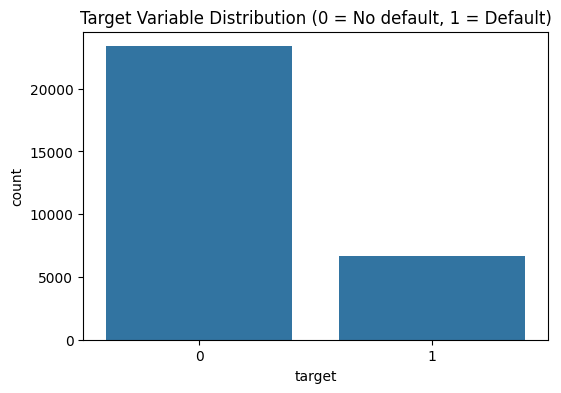

In [13]:
# Cell 5: Target distribution
target_counts = df['target'].value_counts(normalize=True) * 100
print("Target distribution (%):\n", target_counts)

plt.figure(figsize=(6,4))
sns.countplot(x='target', data=df)
plt.title('Target Variable Distribution (0 = No default, 1 = Default)')
plt.show()

In [14]:
# Cell 6: Basic statistics
df.describe()

,id,credit_limit,sex,education,marital_status,age,pay_status_sept,pay_status_aug,pay_status_jul,pay_status_jun,...,bill_amt_jun,bill_amt_may,bill_amt_apr,pay_amt_sept,pay_amt_aug,pay_amt_jul,pay_amt_jun,pay_amt_may,pay_amt_apr,target
count,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,...,30000.000000,30000.000000,30000.000000,30000.000000,3.000000e+04,30000.00000,30000.000000,30000.000000,30000.000000,30000.000000
mean,15000.500000,167484.322667,1.603733,1.853133,1.551867,35.485500,-0.016700,-0.133767,-0.166200,-0.220667,...,43262.948967,40311.400967,38871.760400,5663.580500,5.921163e+03,5225.68150,4826.076867,4799.387633,5215.502567,0.221200
std,8660.398374,129747.661567,0.489129,0.790349,0.521970,9.217904,1.123802,1.197186,1.196868,1.169139,...,64332.856134,60797.155770,59554.107537,16563.280354,2.304087e+04,17606.96147,15666.159744,15278.305679,17777.465775,0.415062
min,1.000000,10000.000000,1.000000,0.000000,0.000000,21.000000,-2.000000,-2.000000,-2.000000,-2.000000,...,-170000.000000,-81334.000000,-339603.000000,0.000000,0.000000e+00,0.00000,0.000000,0.000000,0.000000,0.000000
25%,7500.750000,50000.000000,1.000000,1.000000,1.000000,28.000000,-1.000000,-1.000000,-1.000000,-1.000000,...,2326.750000,1763.000000,1256.000000,1000.000000,8.330000e+02,390.00000,296.000000,252.500000,117.750000,0.000000
50%,15000.500000,140000.000000,2.000000,2.000000,2.000000,34.000000,0.000000,0.000000,0.000000,0.000000,...,19052.000000,18104.500000,17071.000000,2100.000000,2.009000e+03,1800.00000,1500.000000,1500.000000,1500.000000,0.000000
75%,22500.250000,240000.000000,2.000000,2.000000,2.000000,41.000000,0.000000,0.000000,0.000000,0.000000,...,54506.000000,50190.500000,49198.250000,5006.000000,5.000000e+03,4505.00000,4013.250000,4031.500000,4000.000000,0.000000
max,30000.000000,1000000.000000,2.000000,6.000000,3.000000,79.000000,8.000000,8.000000,8.000000,8.000000,...,891586.000000,927171.000000,961664.000000,873552.000000,1.684259e+06,896040.00000,621000.000000,426529.000000,528666.000000,1.000000
